# SAAM Project — Group AD
## AMER + EUR | Scope 1 + Scope 2 | Jan 2014 – Dec 2025
Runs top-to-bottom. All data files must be in the same directory as this notebook.

## Section 1 — Imports and File Paths

In [1]:
# 0 - Imports and File names 

import warnings, re, shutil, os
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
plt.rcParams['figure.dpi'] = 110

# Data files live in the Data/ subfolder relative to this notebook.
# Run the notebook from the SAAM Project directory.
DATA = 'Data'

FILE_STATIC   = f'{DATA}/Static_2025.xlsx'
FILE_RI_M     = f'{DATA}/DS_RI_T_USD_M_2025.xlsx'
FILE_MV_M     = f'{DATA}/DS_MV_T_USD_M_2025.xlsx'
FILE_MV_Y     = f'{DATA}/DS_MV_T_USD_Y_2025.xlsx'
FILE_SCOPE1   = f'{DATA}/DS_CO2_SCOPE_1_Y_2025.xlsx'
FILE_SCOPE2   = f'{DATA}/DS_CO2_SCOPE_2_Y_2025.xlsx'
FILE_REV      = f'{DATA}/DS_REV_Y_2025.xlsx'
FILE_RF       = f'{DATA}/Risk_Free_Rate_2025.xlsx'
FILE_TEMPLATE = 'Archive/Template for Part I-SAAM (1).xlsx'
FILE_OUTPUT   = 'SAAM_Part1_Results.xlsx'

# Create output directories (safe to re-run)
FIG_DIR = 'outputs/figures'
TAB_DIR = 'outputs/tables'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
print('OK')



OK


## Section 2 — Load Data

In [2]:
# 1 - Load data

# Datastream file format: row 0 = broken metadata, row 1 = actual header (name, ISIN, dates).
# Loading with header=0 reads the metadata row as the header; date columns come through as
# human-readable strings that pd.to_datetime can parse. With header=1, dates arrive as
# Excel serial number floats and pd.to_datetime fails silently (all columns dropped).

def load_monthly(path, sheet):
    df = pd.read_excel(path, sheet_name=sheet, index_col=0, header=0)
    df = df[df.index.notna()]
    df.index = df.iloc[:, 0].values; df.index.name = 'ISIN'
    df = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
    cols = pd.to_datetime(df.columns, errors='coerce')
    df = df.loc[:, ~cols.isna()]; df.columns = cols[~cols.isna()]
    return df

def load_annual(path, sheet):
    df = pd.read_excel(path, sheet_name=sheet, index_col=0, header=0)
    df = df[df.index.notna()]
    df.index = df.iloc[:, 0].values; df.index.name = 'ISIN'
    df = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
    yr = {}
    for c in df.columns:
        try:
            y = int(float(str(c)))
            if 1999 <= y <= 2024: yr[c] = y
        except: pass
    df = df[list(yr)]; df.columns = list(yr.values())
    return df

static    = pd.read_excel(FILE_STATIC)
ri_raw    = load_monthly(FILE_RI_M,   'RI')
mv_m_raw  = load_monthly(FILE_MV_M,   'MV')
scope1_raw= load_annual(FILE_SCOPE1,  'Scope1')
scope2_raw= load_annual(FILE_SCOPE2,  'Scope2')
rev_raw   = load_annual(FILE_REV,     'REV')
mv_y_raw  = load_annual(FILE_MV_Y,    'MV')

# Risk-free rate (Fama-French, drop non-numeric rows, convert % to decimal)
_rf = pd.read_excel(FILE_RF, sheet_name='F-F_Research_Data_Factors', header=None)
_rf.columns = range(len(_rf.columns))
_rf = _rf[pd.to_numeric(_rf[0], errors='coerce').notna()][[0, 1]]
_rf.columns = ['yyyymm', 'RF']
_rf['date'] = pd.to_datetime(_rf['yyyymm'].astype(int).astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
rf = _rf.set_index('date')['RF'].astype(float) / 100

print(f'RI monthly:  {ri_raw.shape}  |  MV monthly: {mv_m_raw.shape}')
print(f'Scope1: {scope1_raw.shape}  Scope2: {scope2_raw.shape}  REV: {rev_raw.shape}  MV_Y: {mv_y_raw.shape}')
print(f'RF: {rf.index.min().date()} → {rf.index.max().date()}')

# 2 - Filter to AMER + EUR (Group AD as mentionned in the instruction)

universe = set(static.loc[static['Region'].isin(['AMER','EUR']), 'ISIN'])
print(f'AMER+EUR firms in static: {len(universe)}')

def f(df): return df[df.index.isin(universe)].copy()

ri_f     = f(ri_raw);     mv_m_f  = f(mv_m_raw)
scope1_f = f(scope1_raw); scope2_f= f(scope2_raw)
rev_f    = f(rev_raw);    mv_y_f  = f(mv_y_raw)
static_f = static[static['ISIN'].isin(universe)].set_index('ISIN').copy()

print(f'After filter  RI: {ri_f.shape[0]}  MV_M: {mv_m_f.shape[0]}  Scope1: {scope1_f.shape[0]}')



RI monthly:  (2545, 314)  |  MV monthly: (2545, 314)
Scope1: (2545, 26)  Scope2: (2545, 26)  REV: (2545, 26)  MV_Y: (2545, 26)
RF: 2000-01-31 → 2025-12-31
AMER+EUR firms in static: 1302
After filter  RI: 1302  MV_M: 1302  Scope1: 1302


## Section 3 — Clean RI Data and Compute Returns

In [3]:
# 3 - Data cleaning : low RI filter + monthly returns

# Any RI below 0.5 is treated as missing (near-zero prices cause extreme returns)
ri_clean = ri_f.copy()
ri_clean[ri_clean < 0.5] = np.nan
print(f'RI < 0.5 → NaN: {(ri_f < 0.5).sum().sum():,}')

# Monthly returns: R_t = RI_t / RI_{t-1} - 1. No forward-fill before this step.
ret0 = ri_clean.pct_change(axis=1, fill_method=None)
ret0.replace([np.inf, -np.inf], np.nan, inplace=True)
monthly_cols = ret0.columns.tolist()
print(f'Returns: {ret0.shape}  |  {monthly_cols[0].date()} → {monthly_cols[-1].date()}')


## 4 — Delist corrections

# Firms marked DELIST.DD/MM/YY in their name:
#   - At the delist month: RI → 0  (gives -100% return for that month)
#   - After the delist month: RI → NaN  (firm no longer exists)
name_col = static_f['NAME'] if 'NAME' in static_f.columns else \
           static.set_index('ISIN').loc[static_f.index, 'NAME']

_pat = re.compile(r'DELIST\.([0-9]{2}/[0-9]{2}/[0-9]{2})')
delist_dates = {}
for isin, nm in name_col.items():
    if not isinstance(nm, str): continue
    m = _pat.search(nm)
    if m:
        try: delist_dates[isin] = pd.to_datetime(m.group(1), format='%d/%m/%y')
        except: pass
print(f'Delisted firms: {len(delist_dates)}')

ri_adj = ri_clean.copy()
col_ym = np.array([(c.year, c.month) for c in monthly_cols])

for isin, dt in delist_dates.items():
    if isin not in ri_adj.index: continue
    dy, dm = dt.year, dt.month
    after = (col_ym[:,0] > dy) | ((col_ym[:,0]==dy) & (col_ym[:,1] > dm))
    at    = (col_ym[:,0] == dy) & (col_ym[:,1] == dm)
    loc = ri_adj.index.get_loc(isin)
    ri_adj.iloc[loc, after] = np.nan
    ri_adj.iloc[loc, at]    = 0.0

ret = ri_adj.pct_change(axis=1, fill_method=None)
ret.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Returns (delist-adjusted): {ret.shape}')



RI < 0.5 → NaN: 957
Returns: (1302, 314)  |  1999-12-31 → 2026-01-30
Delisted firms: 107
Returns (delist-adjusted): (1302, 314)


## Section 4 — Annual Data: Market Cap, Revenue, Emissions

In [4]:
# 5 - Foward-fill annual data + carbon metrics

# Forward-fill annual data along the year axis.
# If a firm never reported (all NaN before year Y), we leave it as NaN → excluded from universe.
# If a firm reported in earlier years but not the most recent, we carry the last known value.

def ffill_ann(df):
    return df[sorted(df.columns)].ffill(axis=1)

scope1 = ffill_ann(scope1_f)
scope2 = ffill_ann(scope2_f)
rev    = ffill_ann(rev_f)    / 1000   # kUSD → mUSD
mv_y   = ffill_ann(mv_y_f)            # million USD (annual market cap)

# Total emissions = Scope 1 + Scope 2
em_idx   = scope1.index.intersection(scope2.index)
emissions = scope1.loc[em_idx] + scope2.loc[em_idx]

# Carbon intensity: CI = emissions (tonnes) / revenue (million USD)
ci_all = emissions / rev.reindex(emissions.index)   # tCO2e / mUSD revenue

print(f'Emissions: {emissions.shape}  |  CI: {ci_all.shape}  |  MV_Y: {mv_y.shape}')



Emissions: (1302, 26)  |  CI: (1302, 26)  |  MV_Y: (1302, 26)


## Section 5 — Build Eligible Investment Universe

In [5]:
# 6 - Investment set (end of year 2013-2024)

WINDOW = 120; MIN_OBS = 36; MAX_ZERO = 0.5

delist_ym = {isin: (dt.year, dt.month) for isin, dt in delist_dates.items()}

def dec_col(year):
    cands = [c for c in monthly_cols if c.year == year and c.month == 12]
    return cands[-1] if cands else None

eligible = {}   # year Y → list of ISINs

for Y in range(2013, 2025):
    t_Y  = dec_col(Y);  ti = monthly_cols.index(t_Y)
    ws   = max(0, ti - WINDOW + 1)
    Rw   = ret.iloc[:, ws : ti + 1]

    m_obs  = Rw.notna().sum(axis=1) >= MIN_OBS
    m_prc  = ri_adj[t_Y].notna()
    n_obs  = Rw.notna().sum(axis=1).replace(0, np.nan)
    m_stl  = ((Rw == 0).sum(axis=1) / n_obs).fillna(1) <= MAX_ZERO

    yr_av  = [c for c in emissions.columns if c <= Y]
    ev_em  = emissions[yr_av].notna().any(axis=1) if yr_av else pd.Series(False, index=emissions.index)
    m_co2  = ev_em.reindex(ret.index, fill_value=False)

    def alive(isin):
        ym = delist_ym.get(isin)
        return (ym is None) or (ym[0] > Y) or (ym[0]==Y and ym[1]>12)
    m_nd = pd.Series([alive(i) for i in ret.index], index=ret.index)

    ok = m_obs & m_prc & m_stl & m_co2 & m_nd
    eligible[Y] = ok[ok].index.tolist()
    print(f'{Y}: {len(eligible[Y]):4d} firms  [obs={m_obs.sum()} prc={m_prc.sum()} stale={m_stl.sum()} co2={m_co2.sum()}]')



2013:  813 firms  [obs=1273 prc=1281 stale=1281 co2=820]
2014:  842 firms  [obs=1275 prc=1279 stale=1281 co2=850]
2015:  876 firms  [obs=1277 prc=1283 stale=1284 co2=885]
2016:  900 firms  [obs=1281 prc=1283 stale=1286 co2=907]
2017:  932 firms  [obs=1281 prc=1285 stale=1288 co2=940]
2018:  989 firms  [obs=1284 prc=1285 stale=1289 co2=999]
2019: 1083 firms  [obs=1285 prc=1286 stale=1290 co2=1095]
2020: 1131 firms  [obs=1286 prc=1285 stale=1292 co2=1143]
2021: 1168 firms  [obs=1287 prc=1290 stale=1298 co2=1181]
2022: 1169 firms  [obs=1289 prc=1263 stale=1300 co2=1205]
2023: 1154 firms  [obs=1289 prc=1241 stale=1302 co2=1212]
2024: 1140 firms  [obs=1295 prc=1216 stale=1300 co2=1216]


## Section 6 — Estimate Covariance and Build VW + MVP

In [6]:
# 7 — bh_returns: buy-and-hold ex-post monthly return helper
#     (defined here, at module level, before the optimisation loop)

def bh_returns(firms, w_opt, next_12_cols):
    """Buy-and-hold monthly returns for one year.

    Weights are set at formation date and drift with prices.
    Missing firm returns are treated as 0 in the drift formula only
    (the firm is still held; its weight evolves as if it had 0 return).
    """
    R_next = ret.loc[firms, next_12_cols]
    w = w_opt.copy()
    rets = []
    for col in next_12_cols:
        ri  = np.where(np.isnan(R_next[col].values), 0.0, R_next[col].values)
        rp  = float(w @ ri)
        rets.append(rp)
        if abs(1 + rp) > 1e-12:
            w = w * (1 + ri) / (1 + rp)
    return rets

mvp_r, vw_r = [], []
mvp_idx = []
mvp_w_store = {}   # store MVP weights for Part II
vw_w_ann    = {}   # store annual VW weights (from annual cap) for Part II

for Y in range(2013, 2025):
    t_Y  = dec_col(Y);  ti = monthly_cols.index(t_Y)
    firms= eligible[Y]
    if not firms: continue
    next_12 = monthly_cols[ti + 1 : ti + 13]

    # ── MVP ──────────────────────────────────────────────────────────────────
    ws   = max(0, ti - WINDOW + 1)
    Rest = ret.loc[firms, monthly_cols[ws : ti + 1]]
    Rf   = Rest.fillna(Rest.mean(axis=0))
    Sig  = Rf.T.cov().values
    n    = len(firms)
    w    = cp.Variable(n)
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sig)), [cp.sum(w)==1, w>=0])
    try:    prob.solve(solver=cp.CLARABEL, verbose=False)
    except: pass
    if prob.status not in ('optimal','optimal_inaccurate') or w.value is None:
        w_mvp = np.full(n, 1/n)
        print(f'{Y}: MVP fallback to equal weight')
    else:
        w_mvp = np.clip(w.value, 0, None); w_mvp /= w_mvp.sum()
    mvp_w_store[Y] = pd.Series(w_mvp, index=firms)

    # ── VW (monthly market-cap reweighting) ──────────────────────────────────
    Rnext = ret.loc[firms, next_12]
    prev  = t_Y
    for col in next_12:
        cap = (mv_m_f.loc[mv_m_f.index.isin(firms), prev].astype(float).replace(0, np.nan).dropna()
               if prev in mv_m_f.columns else pd.Series(dtype=float))
        act = cap.index.intersection(Rnext.index)
        if len(act) == 0 or cap.loc[act].sum() == 0:
            vw_r.append(0.0)
        else:
            wc  = cap.loc[act] / cap.loc[act].sum()
            vw_r.append(float(wc @ Rnext.loc[act, col].fillna(0)))
        prev = col

    # ── Store annual cap-based VW weights (for Part II carbon constraint) ────
    if Y in mv_y.columns:
        cap_y = mv_y.loc[mv_y.index.isin(firms), Y].astype(float).replace(0, np.nan).dropna()
    else:
        cap_y = pd.Series(dtype=float)
    if len(cap_y) > 0:
        vw_w_ann[Y] = cap_y / cap_y.sum()
    else:
        vw_w_ann[Y] = pd.Series(1/n, index=firms)

    mvp_r.extend(bh_returns(firms, w_mvp, next_12))
    mvp_idx.extend(next_12)
    print(f'{Y}: MVP nnz={(w_mvp>1e-4).sum():3d}  [{next_12[0].date()}…{next_12[-1].date()}]')

idx144  = mvp_idx
mvp_ret = pd.Series(mvp_r, index=idx144)
vw_ret  = pd.Series(vw_r,  index=idx144)
print(f'\nSeries length  MVP: {len(mvp_ret)}  VW: {len(vw_ret)}')



2013: MVP nnz= 24  [2014-01-31…2014-12-31]


2014: MVP nnz= 30  [2015-01-30…2015-12-31]


2015: MVP nnz= 27  [2016-01-29…2016-12-30]


2016: MVP nnz= 29  [2017-01-31…2017-12-29]


2017: MVP nnz= 33  [2018-01-31…2018-12-31]


...

2020: MVP nnz= 40  [2021-01-29…2021-12-31]


2021: MVP nnz= 50  [2022-01-31…2022-12-30]


2022: MVP nnz= 36  [2023-01-31…2023-12-29]


2023: MVP nnz= 27  [2024-01-31…2024-12-31]


2024: MVP nnz= 30  [2025-01-31…2025-12-31]

Series length  MVP: 144  VW: 144


## Section 7 — Part I: Performance Statistics, Figures, and Excel Export


=== Part I: Performance Summary ===
                      VW Benchmark     MVP
Ann. avg. return            0.1145  0.0616
Ann. volatility             0.1422  0.1198
Ann. cumulative ret.        0.1096  0.0558
Sharpe ratio                0.6796  0.3650
Min monthly                -0.1320 -0.1273
Max monthly                 0.1294  0.1150


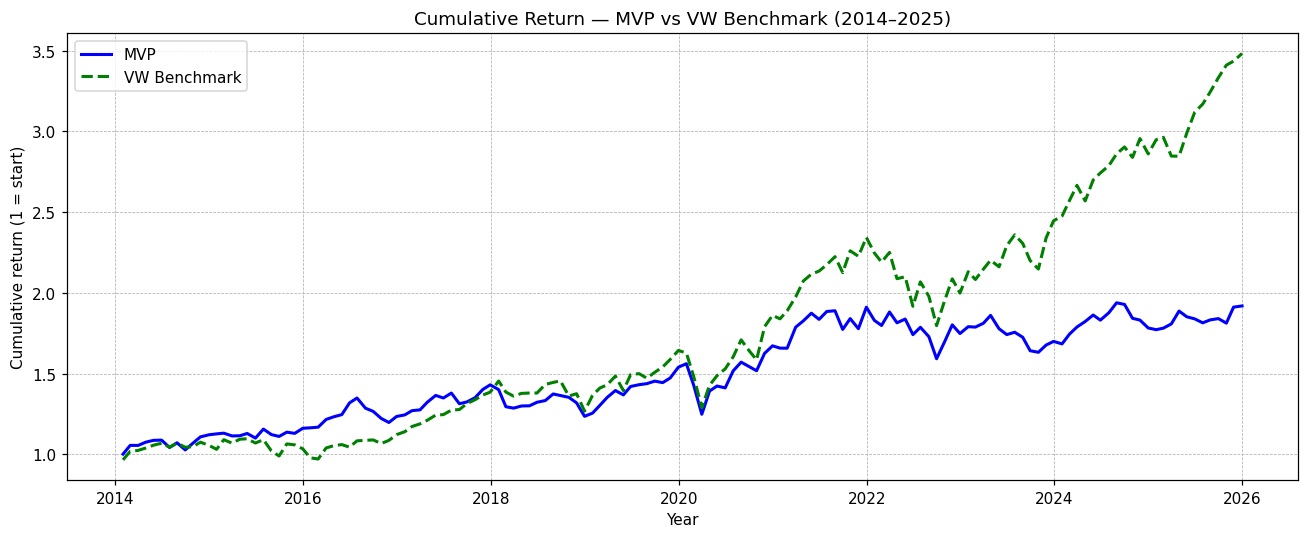

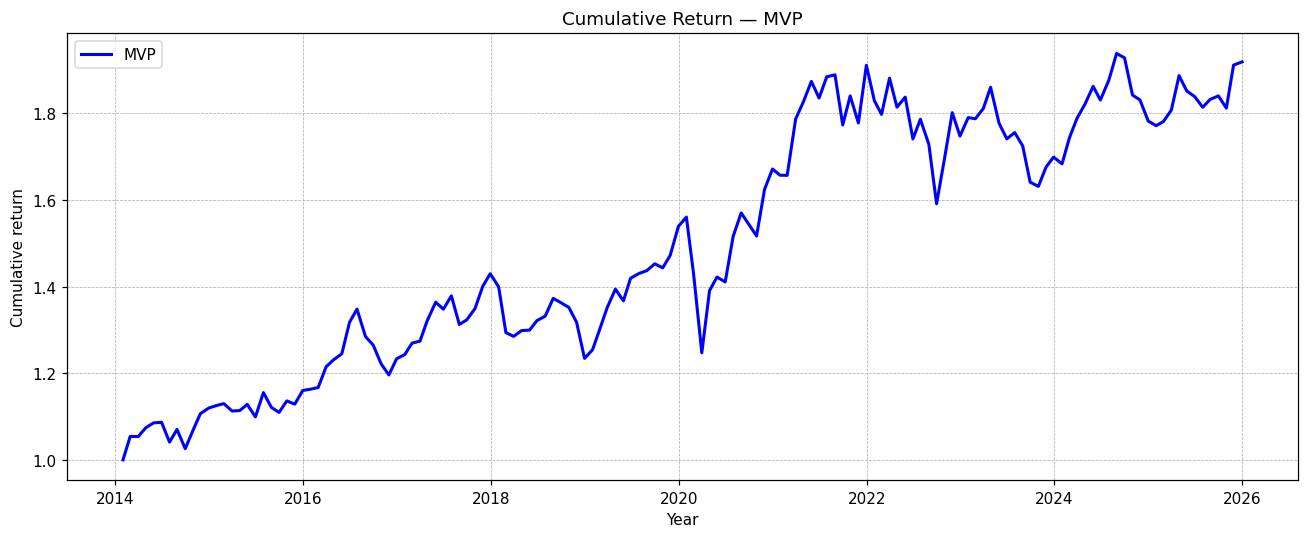

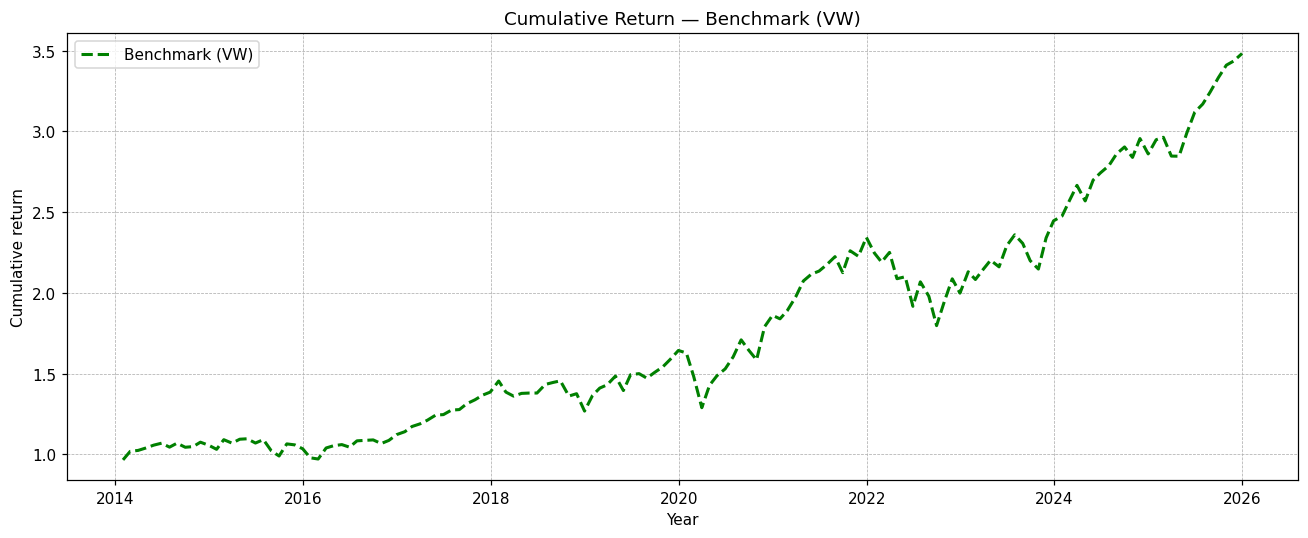


Note: template not found at 'Archive/Template for Part I-SAAM (1).xlsx' — Excel export skipped.


In [7]:
# 8 - Part I summary stats + plots + excel template

rf_a = rf.reindex(pd.DatetimeIndex(idx144)).fillna(rf.mean())

def perf(r, label):
    T = len(r)
    return pd.Series({
        'Ann. avg. return'     : r.mean()*12,
        'Ann. volatility'      : r.std()*np.sqrt(12),
        'Ann. cumulative ret.' : (1+r).prod()**(12/T)-1,
        'Sharpe ratio'         : ((r-rf_a).mean()*12) / (r.std()*np.sqrt(12)),
        'Min monthly'          : r.min(),
        'Max monthly'          : r.max(),
    }, name=label)

s1 = perf(vw_ret,  'VW Benchmark')
s2 = perf(mvp_ret, 'MVP')
tbl1 = pd.concat([s1, s2], axis=1)
print('\n=== Part I: Performance Summary ===')
print(tbl1.to_string(float_format=lambda x: f'{x:.4f}'))

cum_mvp = (1 + mvp_ret).cumprod()
cum_vw  = (1 + vw_ret).cumprod()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(cum_mvp, 'b-',  lw=2, label='MVP')
ax.plot(cum_vw,  'g--', lw=2, label='VW Benchmark')
ax.set(title='Cumulative Return — MVP vs VW Benchmark (2014–2025)',
       xlabel='Year', ylabel='Cumulative return (1 = start)')
ax.grid(ls='--', lw=0.5); ax.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cumulative_returns_part1.png', dpi=150, bbox_inches='tight'); plt.show()

# Individual plots for template
for cum, col, ls, label, fname in [
        (cum_mvp, 'blue',  '-',  'MVP',            'cum_mvp.png'),
        (cum_vw,  'green', '--', 'Benchmark (VW)', 'cum_vw.png')]:
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(cum, color=col, ls=ls, lw=2, label=label)
    ax.set(title=f'Cumulative Return — {label}', xlabel='Year', ylabel='Cumulative return')
    ax.grid(ls='--', lw=0.5); ax.legend(); plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/{fname}', dpi=150, bbox_inches='tight'); plt.show()

# Fill Excel template (Part I)
try:
    shutil.copy(FILE_TEMPLATE, FILE_OUTPUT)
    wb = load_workbook(FILE_OUTPUT); ws_xl = wb.active
    for i, (vv, mv) in enumerate(zip(s1.values, s2.values)):
        ws_xl.cell(3+i, 2).value = round(float(vv), 8)
        ws_xl.cell(3+i, 3).value = round(float(mv), 8)
    for i, d in enumerate(idx144):
        ws_xl.cell(3+i, 6).value = round(float(vw_ret.iloc[i]),  8)
        ws_xl.cell(3+i, 7).value = round(float(mvp_ret.iloc[i]), 8)
    for anch, fp in [(f'B9', f'{FIG_DIR}/cum_vw.png'), ('C9', f'{FIG_DIR}/cum_mvp.png')]:
        img = XLImage(fp); img.width=400; img.height=220; ws_xl.add_image(img, anch)
    wb.save(FILE_OUTPUT)
    print(f'\nPart I template saved → {FILE_OUTPUT}')
except FileNotFoundError:
    print(f'\nNote: template not found at {FILE_TEMPLATE!r} — Excel export skipped.')


## Part II - Carbon Analysis



## Section 8 — Carbon Metrics: VW and MVP

In [8]:
# 9 - Carbon footprint and WACI for MVP and VW

# For each year Y we compute two metrics:
#
#   Carbon Footprint (CF) = Σ_i α_i × (E_i / Cap_i)
#      units: tCO2e per million $ invested
#      uses annual market cap (mv_y) because it represents total firm equity value
#
#   WACI = Σ_i α_i × CI_i   where CI_i = E_i / Rev_i
#      units: tCO2e per million $ revenue

def get_carbon_vec(firms, Y):
    """Return cf_vec, waci_vec for eligible firms at year Y.
    cf_vec[i] = E_i / Cap_i (annual),  waci_vec[i] = E_i / Rev_i.
    Returns arrays aligned with `firms` list; np.nan where data missing."""
    firms = list(firms)

    # Emissions at year Y (forward-filled)
    em_col = Y if Y in emissions.columns else max(c for c in emissions.columns if c <= Y)
    em = emissions.reindex(firms)[em_col]   # tCO2e

    # Annual market cap
    if Y in mv_y.columns:
        cap = mv_y.reindex(firms)[Y]
    else:
        # fall back to Dec-Y monthly cap if annual not available
        t_Y = dec_col(Y)
        cap = mv_m_f.reindex(firms)[t_Y] if t_Y in mv_m_f.columns else pd.Series(np.nan, index=firms)

    rev_col = Y if Y in rev.columns else max(c for c in rev.columns if c <= Y)
    rv = rev.reindex(firms)[rev_col]   # mUSD

    cf_v   = (em / cap).values.astype(float)    # tCO2/mUSD invested
    waci_v = (em / rv).values.astype(float)     # tCO2/mUSD revenue
    return cf_v, waci_v, firms

# Compute annual CF and WACI for MVP and VW
years_out = list(range(2014, 2026))
cf_mvp_ts   = {}; waci_mvp_ts  = {}
cf_vw_ts    = {}; waci_vw_ts   = {}

for Y in range(2013, 2025):
    firms = eligible[Y]
    cf_v, waci_v, _ = get_carbon_vec(firms, Y)

    # MVP weights
    w_mvp = mvp_w_store[Y].values
    # Annual cap-based VW weights
    w_vw  = vw_w_ann[Y].reindex(firms).fillna(0).values
    if w_vw.sum() > 0: w_vw /= w_vw.sum()

    # NaN-safe dot product: set NaN entries to 0 for the sum
    def safe_dot(w, v):
        mask = ~np.isnan(v)
        wm = w * mask.astype(float)
        s  = wm.sum()
        return float(wm @ np.where(mask, v, 0)) / s if s > 0 else np.nan

    cf_mvp_ts[Y+1]   = safe_dot(w_mvp, cf_v)
    waci_mvp_ts[Y+1] = safe_dot(w_mvp, waci_v)
    cf_vw_ts[Y+1]    = safe_dot(w_vw,  cf_v)
    waci_vw_ts[Y+1]  = safe_dot(w_vw,  waci_v)

cf_mvp_s   = pd.Series(cf_mvp_ts)
waci_mvp_s = pd.Series(waci_mvp_ts)
cf_vw_s    = pd.Series(cf_vw_ts)
waci_vw_s  = pd.Series(waci_vw_ts)

print('Year   CF_MVP   CF_VW    WACI_MVP  WACI_VW')
for y in years_out:
    print(f'{y}   {cf_mvp_s[y]:.2f}    {cf_vw_s[y]:.2f}    {waci_mvp_s[y]:.2f}     {waci_vw_s[y]:.2f}')

# 10 - Top 10 carbon-intensive firms (driving VW portfolio CF)

# Find the firms with the highest carbon footprint contribution in the VW portfolio
# We use a representative year (e.g., 2019) to identify the main contributors.
# Contribution = w_vw_i × (E_i / Cap_i)

Y_ref = 2019   # reference year (mid-sample)
firms_ref = eligible[Y_ref]
cf_v, waci_v, _ = get_carbon_vec(firms_ref, Y_ref)
w_vw_ref = vw_w_ann[Y_ref].reindex(firms_ref).fillna(0).values
if w_vw_ref.sum() > 0: w_vw_ref /= w_vw_ref.sum()

contrib = np.where(np.isnan(cf_v), 0.0, w_vw_ref * cf_v)
top10_idx = np.argsort(contrib)[::-1][:10]

top10 = pd.DataFrame({
    'ISIN'       : [firms_ref[i] for i in top10_idx],
    'Name'       : [static_f.loc[firms_ref[i], 'NAME'] if firms_ref[i] in static_f.index
                    else 'N/A' for i in top10_idx],
    'CF contrib' : [round(contrib[i], 4) for i in top10_idx],
    'CI (tCO2/mUSD rev)': [round(float(waci_v[i]), 2) if not np.isnan(waci_v[i]) else np.nan
                            for i in top10_idx],
    'w_vw (%)' : [round(w_vw_ref[i]*100, 2) for i in top10_idx]
})

print(f'Top 10 carbon-footprint contributors in VW portfolio ({Y_ref})')
print(top10.to_string(index=False))

# 10b — MVP portfolio analysis: top-10 holdings, carbon contributors, HHI
#        (supports the report claim that the MVP over-concentrates in utilities)

Y_mvp_ref = 2019
firms_mvp = eligible[Y_mvp_ref]
w_mvp_ref = mvp_w_store[Y_mvp_ref].reindex(firms_mvp).fillna(0).values

# — Top-10 MVP holdings by weight —
top10m_idx = np.argsort(w_mvp_ref)[::-1][:10]
cf_v_mvp, waci_v_mvp, _ = get_carbon_vec(firms_mvp, Y_mvp_ref)
top10_mvp = pd.DataFrame({
    "ISIN"         : [firms_mvp[i] for i in top10m_idx],
    "Name"         : [static_f.loc[firms_mvp[i], "NAME"]
                       if firms_mvp[i] in static_f.index else "N/A"
                       for i in top10m_idx],
    "Weight (%)"   : [round(w_mvp_ref[i]*100, 3) for i in top10m_idx],
    "CF (tCO2/m$)" : [round(float(cf_v_mvp[i]), 1) if not np.isnan(cf_v_mvp[i]) else np.nan
                       for i in top10m_idx],
})
print(f"\nTop-10 MVP holdings by weight ({Y_mvp_ref})")
print(top10_mvp.to_string(index=False))

# — Top-10 MVP carbon contributors (w_i * CF_i) —
contrib_mvp = np.where(np.isnan(cf_v_mvp), 0.0, w_mvp_ref * cf_v_mvp)
top10mc_idx = np.argsort(contrib_mvp)[::-1][:10]
top10_mvp_cf = pd.DataFrame({
    "ISIN"       : [firms_mvp[i] for i in top10mc_idx],
    "Name"       : [static_f.loc[firms_mvp[i], "NAME"]
                    if firms_mvp[i] in static_f.index else "N/A"
                    for i in top10mc_idx],
    "CF contrib" : [round(contrib_mvp[i], 4) for i in top10mc_idx],
    "CF (tCO2/m$)": [round(float(cf_v_mvp[i]), 1) if not np.isnan(cf_v_mvp[i]) else np.nan
                      for i in top10mc_idx],
    "Weight (%)" : [round(w_mvp_ref[i]*100, 3) for i in top10mc_idx],
})
print(f"\nTop-10 MVP carbon-footprint contributors ({Y_mvp_ref})")
print(top10_mvp_cf.to_string(index=False))

# — Annual MVP concentration: HHI and effective number of assets (ENA) —
hhi_rows = []
for Y in range(2013, 2025):
    w_y = mvp_w_store[Y].values
    nnz = (w_y > 1e-4).sum()
    hhi = float((w_y**2).sum())
    ena = 1.0 / hhi if hhi > 0 else np.nan
    hhi_rows.append({"Year": Y+1, "nnz (>0.01%)": nnz,
                     "HHI": round(hhi, 4), "ENA": round(ena, 1)})
hhi_df = pd.DataFrame(hhi_rows)
print("\nMVP concentration by year (HHI = Herfindahl-Hirschman Index,")
print("ENA = effective number of assets = 1/HHI)")
print(hhi_df.to_string(index=False))



Year   CF_MVP   CF_VW    WACI_MVP  WACI_VW
2014   144.30    183.81    190.66     194.90
2015   249.53    165.49    466.71     188.48
2016   89.19    153.05    153.81     197.36
2017   77.00    163.65    108.93     200.30
2018   100.63    138.67    209.83     210.79
2019   390.09    112.18    738.98     175.34
2020   160.85    114.16    346.50     180.72
2021   189.84    88.53    486.01     164.13
2022   117.26    80.28    284.90     159.79
2023   94.80    65.72    209.13     132.01
2024   79.61    68.32    135.02     110.86
2025   95.97    60.09    150.02     100.95
Top 10 carbon-footprint contributors in VW portfolio (2019)
        ISIN                 Name  CF contrib  CI (tCO2/mUSD rev)  w_vw (%)
CH0012214059               HOLCIM      4.4144             4668.74      0.10
US30231G1022          EXXON MOBIL      3.7642              393.80      1.10
DE0007037129                  RWE      3.2995             6279.98      0.05
US8425871071             SOUTHERN      3.0200             3756.

## Section 9 — Carbon-Constrained Portfolios: MVP50, VW50, VWNZ

In [9]:
# 11 - P_mv(0.5): MVP with 50% carbon footprint reduction

# Each year: solve same MVP optimization but add CF constraint:
#   Σ_i α_i × (E_i/Cap_i) ≤ 0.5 × CF(unconstrained MVP)_Y
# If constraint is infeasible, fall back to unconstrained MVP with a warning.

mvp50_r     = []; mvp50_w_store = {}

# ── Diagnostic: missing CF data per year ────────────────────────────────────
# Eligible firms already have at least one carbon observation (filter F4),
# but annual market cap (mv_y) may be missing for some, making CF = E/Cap = NaN.
# We use cf_clean = np.where(np.isnan(cf_v), 0.0, cf_v) in constraints,
# which treats those firms as carbon-neutral. This likely understates portfolio CF.
print("\n--- Missing CF data diagnostic (constrained portfolios) ---")
for _Y in range(2013, 2025):
    _firms = eligible[_Y]
    _cf_v, _, _ = get_carbon_vec(_firms, _Y)
    _n_miss = int(np.isnan(_cf_v).sum())
    if _n_miss > 0:
        _w_vw_ref = vw_w_ann[_Y].reindex(_firms).fillna(0).values
        _w_vw_ref = _w_vw_ref / _w_vw_ref.sum() if _w_vw_ref.sum() > 0 else _w_vw_ref
        _miss_weight = float(np.array(_w_vw_ref)[np.isnan(_cf_v)].sum())
        print(f"  {_Y}: {_n_miss}/{len(_firms)} firms missing CF  VW weight in missing: {_miss_weight:.3f}")
    else:
        print(f"  {_Y}: no missing CF data")

for Y in range(2013, 2025):
    t_Y  = dec_col(Y);  ti = monthly_cols.index(t_Y)
    firms= eligible[Y]
    if not firms: continue
    next_12 = monthly_cols[ti + 1 : ti + 13]

    ws   = max(0, ti - WINDOW + 1)
    Rest = ret.loc[firms, monthly_cols[ws : ti + 1]]
    Rf   = Rest.fillna(Rest.mean(axis=0))
    Sig  = Rf.T.cov().values
    n    = len(firms)

    # Carbon footprint vector
    cf_v, _, _ = get_carbon_vec(firms, Y)
    cf_clean   = np.where(np.isnan(cf_v), 0.0, cf_v)  # treat missing as 0 in constraint

    # Target: 50% of unconstrained MVP footprint
    w_mvp = mvp_w_store[Y].values
    cf_mvp_ref = float(w_mvp @ cf_clean)
    target = 0.5 * cf_mvp_ref

    w = cp.Variable(n)
    constraints = [cp.sum(w)==1, w>=0, cf_clean @ w <= target]
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sig)), constraints)
    try:    prob.solve(solver=cp.CLARABEL, verbose=False)
    except: pass

    if prob.status not in ('optimal','optimal_inaccurate') or w.value is None:
        print(f'{Y}: P_mv(0.5) infeasible — using unconstrained MVP')
        w_opt = w_mvp
    else:
        w_opt = np.clip(w.value, 0, None); w_opt /= w_opt.sum()

    mvp50_w_store[Y] = pd.Series(w_opt, index=firms)
    mvp50_r.extend(bh_returns(firms, w_opt, next_12))

    cf_achieved = float(w_opt @ cf_clean)
    print(f'{Y}: CF_target={target:.2f}  CF_achieved={cf_achieved:.2f}  '
          f'reduction={100*(1-cf_achieved/cf_mvp_ref):.1f}%')

mvp50_ret = pd.Series(mvp50_r, index=idx144)

# 12 - P_vw(0.5): tracking-error minimization vs VW with 50% CF reduction

# Minimize (α - α_vw)' Σ (α - α_vw) subject to CF(α) ≤ 0.5 × CF(VW)
# CF(VW) = Σ_i (Cap_i / Cap_total) × (E_i / Cap_i) = Σ_i E_i / Cap_total

vw50_r = []; vw50_w_store = {}

for Y in range(2013, 2025):
    t_Y  = dec_col(Y);  ti = monthly_cols.index(t_Y)
    firms= eligible[Y]
    if not firms: continue
    next_12 = monthly_cols[ti + 1 : ti + 13]

    ws   = max(0, ti - WINDOW + 1)
    Rest = ret.loc[firms, monthly_cols[ws : ti + 1]]
    Rf   = Rest.fillna(Rest.mean(axis=0))
    Sig  = Rf.T.cov().values
    n    = len(firms)

    # Annual cap-based VW weights
    w_vw = vw_w_ann[Y].reindex(firms).fillna(0).values
    if w_vw.sum() > 0: w_vw /= w_vw.sum()

    # Carbon constraint
    cf_v, _, _ = get_carbon_vec(firms, Y)
    cf_clean   = np.where(np.isnan(cf_v), 0.0, cf_v)
    cf_vw_ref  = float(w_vw @ cf_clean)
    target     = 0.5 * cf_vw_ref

    w = cp.Variable(n)
    obj = cp.quad_form(w - w_vw, Sig)
    constraints = [cp.sum(w)==1, w>=0, cf_clean @ w <= target]
    prob = cp.Problem(cp.Minimize(obj), constraints)
    try:    prob.solve(solver=cp.CLARABEL, verbose=False)
    except: pass

    if prob.status not in ('optimal','optimal_inaccurate') or w.value is None:
        print(f'{Y}: P_vw(0.5) infeasible — using VW weights')
        w_opt = w_vw
    else:
        w_opt = np.clip(w.value, 0, None); w_opt /= w_opt.sum()

    vw50_w_store[Y] = pd.Series(w_opt, index=firms)
    vw50_r.extend(bh_returns(firms, w_opt, next_12))

    cf_achieved = float(w_opt @ cf_clean)
    # Realized tracking error (ex-ante)
    diff = w_opt - w_vw
    te   = np.sqrt(float(diff @ Sig @ diff)) * np.sqrt(12) * 100
    print(f'{Y}: CF_target={target:.2f}  CF_achieved={cf_achieved:.2f}  '
          f'reduction={100*(1-cf_achieved/cf_vw_ref):.1f}%  TE={te:.2f}%')

vw50_ret = pd.Series(vw50_r, index=idx144)

# 13 - P_vw(NZ): net-zero portfolio (10%/year decarbonization)

# The net-zero portfolio reduces CF by 10% per year relative to the VW baseline at 2013.
# Constraint at year Y:  CF(α_Y) ≤ (1-0.10)^(Y - 2013 + 1) × CF(VW)_2013

THETA = 0.10   # annual decarbonization rate
Y0    = 2013

# First compute CF(VW)_2013 (the baseline)
firms_0 = eligible[Y0]
cf_v0, _, _ = get_carbon_vec(firms_0, Y0)
cf_clean0   = np.where(np.isnan(cf_v0), 0.0, cf_v0)
w_vw0       = vw_w_ann[Y0].reindex(firms_0).fillna(0).values
if w_vw0.sum() > 0: w_vw0 /= w_vw0.sum()
CF_baseline = float(w_vw0 @ cf_clean0)
print(f'CF(VW) baseline at 2013 = {CF_baseline:.4f} tCO2/mUSD invested')

vwnz_r = []; vwnz_w_store = {}

for Y in range(2013, 2025):
    t_Y  = dec_col(Y);  ti = monthly_cols.index(t_Y)
    firms= eligible[Y]
    if not firms: continue
    next_12 = monthly_cols[ti + 1 : ti + 13]

    ws   = max(0, ti - WINDOW + 1)
    Rest = ret.loc[firms, monthly_cols[ws : ti + 1]]
    Rf   = Rest.fillna(Rest.mean(axis=0))
    Sig  = Rf.T.cov().values
    n    = len(firms)

    w_vw = vw_w_ann[Y].reindex(firms).fillna(0).values
    if w_vw.sum() > 0: w_vw /= w_vw.sum()

    cf_v, _, _ = get_carbon_vec(firms, Y)
    cf_clean   = np.where(np.isnan(cf_v), 0.0, cf_v)

    # Net-zero target for this year
    target = (1 - THETA) ** (Y - Y0 + 1) * CF_baseline

    w = cp.Variable(n)
    obj = cp.quad_form(w - w_vw, Sig)
    constraints = [cp.sum(w)==1, w>=0, cf_clean @ w <= target]
    prob = cp.Problem(cp.Minimize(obj), constraints)
    try:    prob.solve(solver=cp.CLARABEL, verbose=False)
    except: pass

    if prob.status not in ('optimal','optimal_inaccurate') or w.value is None:
        print(f'{Y}: P_vw(NZ) infeasible — using VW weights')
        w_opt = w_vw
    else:
        w_opt = np.clip(w.value, 0, None); w_opt /= w_opt.sum()

    vwnz_w_store[Y] = pd.Series(w_opt, index=firms)
    vwnz_r.extend(bh_returns(firms, w_opt, next_12))

    cf_achieved = float(w_opt @ cf_clean)
    diff = w_opt - w_vw
    te   = np.sqrt(float(diff @ Sig @ diff)) * np.sqrt(12) * 100
    pct  = 100 * (1 - (1 - THETA)**(Y - Y0 + 1))
    print(f'{Y}: target CF={target:.3f} ({pct:.0f}% below baseline)  '
          f'achieved={cf_achieved:.3f}  TE={te:.2f}%')

vwnz_ret = pd.Series(vwnz_r, index=idx144)




--- Missing CF data diagnostic (constrained portfolios) ---
  2013: no missing CF data
  2014: no missing CF data
  2015: no missing CF data
  2016: no missing CF data
  2017: no missing CF data
  2018: no missing CF data
  2019: no missing CF data
  2020: no missing CF data
  2021: no missing CF data
  2022: no missing CF data
  2023: no missing CF data
  2024: no missing CF data


2013: CF_target=72.15  CF_achieved=72.15  reduction=50.0%


2014: CF_target=124.77  CF_achieved=124.76  reduction=50.0%


2015: CF_target=44.59  CF_achieved=44.59  reduction=50.0%


2016: CF_target=38.50  CF_achieved=38.50  reduction=50.0%


...

2020: target CF=79.124 (57% below baseline)  achieved=78.057  TE=0.00%


2021: target CF=71.212 (61% below baseline)  achieved=70.481  TE=0.00%


2022: target CF=64.090 (65% below baseline)  achieved=63.066  TE=0.00%


2023: target CF=57.681 (69% below baseline)  achieved=57.104  TE=0.00%


2024: target CF=51.913 (72% below baseline)  achieved=51.459  TE=0.00%


## Section 10 — Carbon Metrics: All Portfolios

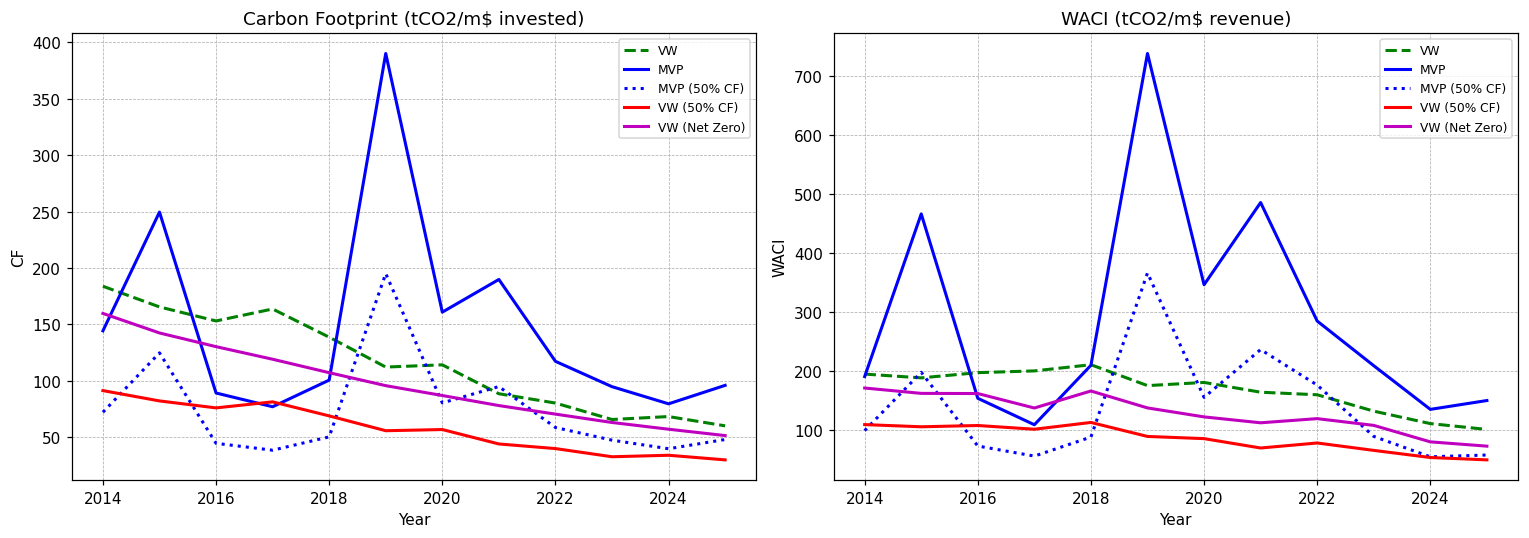

In [10]:
# 14 - Carbon metrics for all portfolios over time

# Compute CF and WACI for P_mv(0.5), P_vw(0.5), P_vw(NZ)
cf_mvp50_ts={}; waci_mvp50_ts={}; cf_vw50_ts={}; waci_vw50_ts={}; cf_vwnz_ts={}; waci_vwnz_ts={}

for Y in range(2013, 2025):
    firms = eligible[Y]
    cf_v, waci_v, _ = get_carbon_vec(firms, Y)

    def sd(ws, v):
        ww = np.array(ws); mask = ~np.isnan(v)
        wm = ww * mask; s = wm.sum()
        return float(wm @ np.where(mask, v, 0)) / s if s > 0 else np.nan

    w50m  = mvp50_w_store[Y].values if Y in mvp50_w_store else None
    w50v  = vw50_w_store[Y].values  if Y in vw50_w_store  else None
    wnzv  = vwnz_w_store[Y].values  if Y in vwnz_w_store  else None

    if w50m is not None:
        cf_mvp50_ts[Y+1]   = sd(w50m, cf_v)
        waci_mvp50_ts[Y+1] = sd(w50m, waci_v)
    if w50v is not None:
        cf_vw50_ts[Y+1]    = sd(w50v, cf_v)
        waci_vw50_ts[Y+1]  = sd(w50v, waci_v)
    if wnzv is not None:
        cf_vwnz_ts[Y+1]    = sd(wnzv, cf_v)
        waci_vwnz_ts[Y+1]  = sd(wnzv, waci_v)

cf_mvp50_s   = pd.Series(cf_mvp50_ts)
cf_vw50_s    = pd.Series(cf_vw50_ts)
cf_vwnz_s    = pd.Series(cf_vwnz_ts)
waci_mvp50_s = pd.Series(waci_mvp50_ts)
waci_vw50_s  = pd.Series(waci_vw50_ts)
waci_vwnz_s  = pd.Series(waci_vwnz_ts)

# ── Carbon Footprint evolution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cf_vw_s,    'g--', lw=2, label='VW')
ax.plot(cf_mvp_s,   'b-',  lw=2, label='MVP')
ax.plot(cf_mvp50_s, 'b:',  lw=2, label='MVP (50% CF)')
ax.plot(cf_vw50_s,  'r-',  lw=2, label='VW (50% CF)')
ax.plot(cf_vwnz_s,  'm-',  lw=2, label='VW (Net Zero)')
ax.set(title='Carbon Footprint (tCO2/m$ invested)', xlabel='Year', ylabel='CF')
ax.legend(fontsize=8); ax.grid(ls='--', lw=0.5)

ax = axes[1]
ax.plot(waci_vw_s,    'g--', lw=2, label='VW')
ax.plot(waci_mvp_s,   'b-',  lw=2, label='MVP')
ax.plot(waci_mvp50_s, 'b:',  lw=2, label='MVP (50% CF)')
ax.plot(waci_vw50_s,  'r-',  lw=2, label='VW (50% CF)')
ax.plot(waci_vwnz_s,  'm-',  lw=2, label='VW (Net Zero)')
ax.set(title='WACI (tCO2/m$ revenue)', xlabel='Year', ylabel='WACI')
ax.legend(fontsize=8); ax.grid(ls='--', lw=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/carbon_metrics_evolution.png', dpi=150, bbox_inches='tight')
plt.show()



## Section 11 — Figures and Final Performance Summary

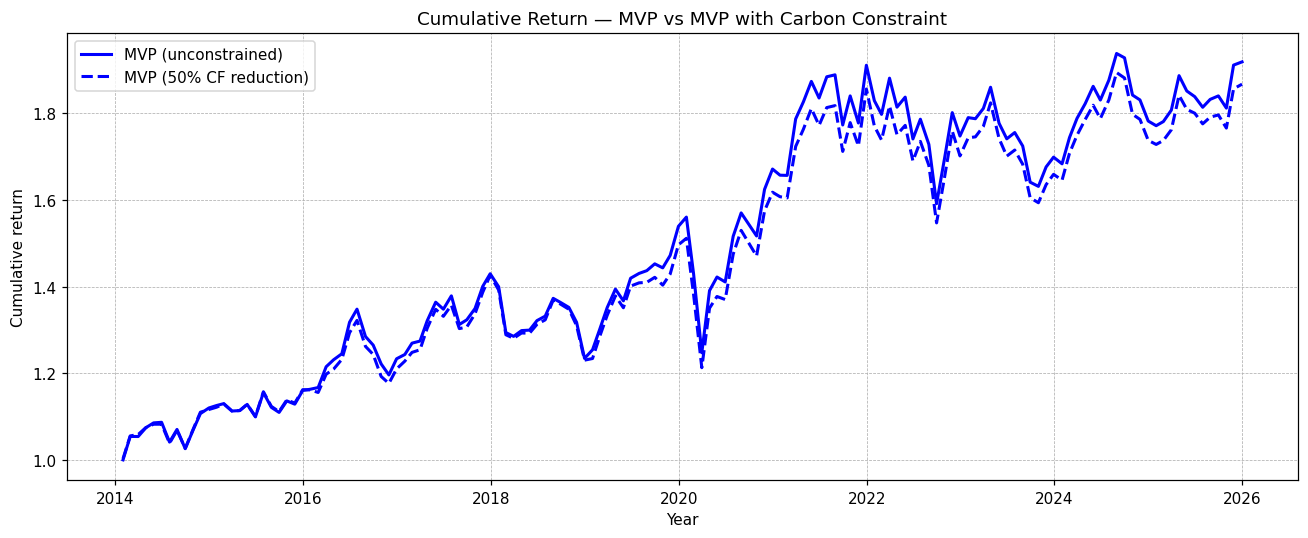

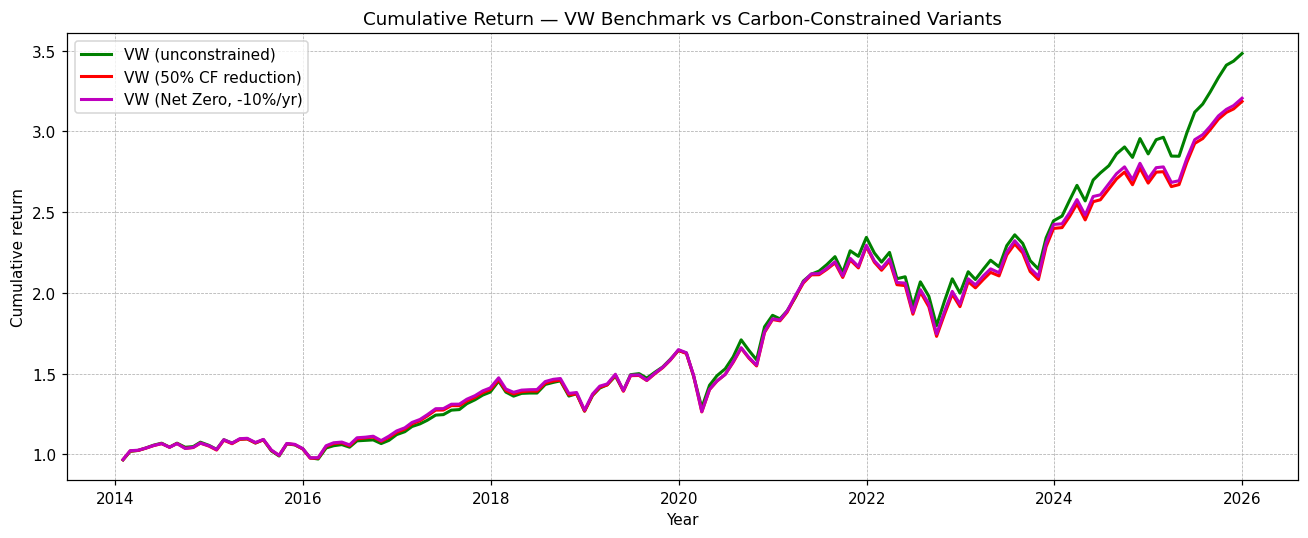

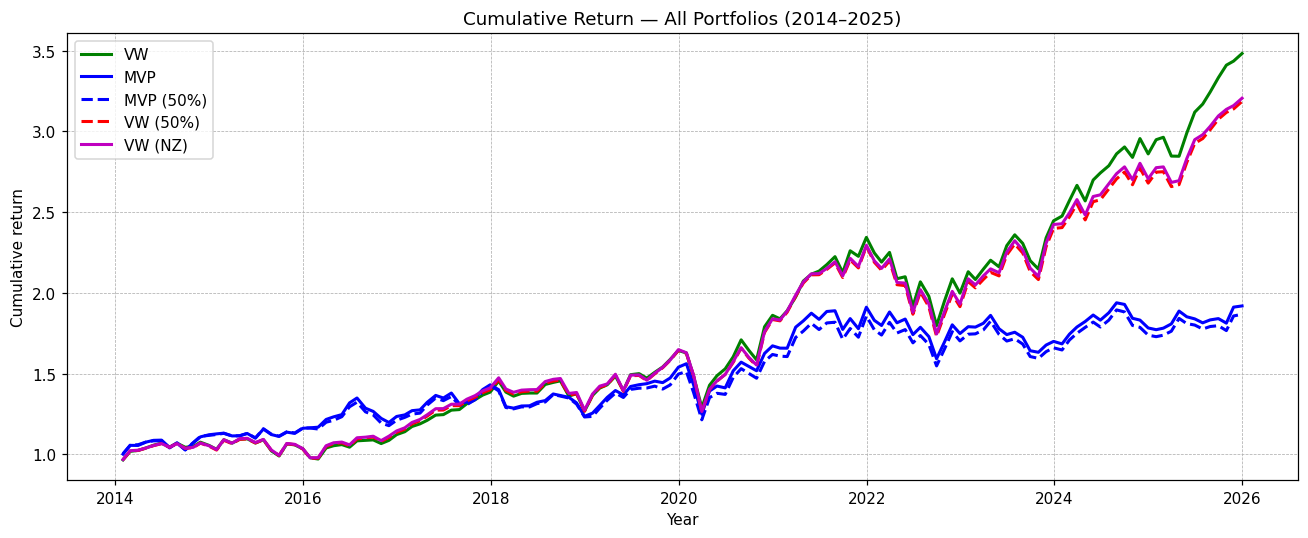


=== Full Performance Summary — Jan 2014 to Dec 2025 ===
                      VW Benchmark     MVP  MVP (50% CF)  VW (50% CF)  VW (Net Zero)
Ann. avg. return            0.1145  0.0616        0.0592       0.1073         0.1078
Ann. volatility             0.1422  0.1198        0.1186       0.1440         0.1440
Ann. cumulative ret.        0.1096  0.0558        0.0534       0.1014         0.1019
Sharpe ratio                0.6796  0.3650        0.3483       0.6210         0.6246
Min monthly                -0.1320 -0.1273       -0.1223      -0.1505        -0.1507
Max monthly                 0.1294  0.1150        0.1132       0.1341         0.1337

=== Average Annual Carbon Footprint (tCO2 / m$ invested) ===
            Avg CF
VW        116.1619
MVP       149.0891
MVP (50%)  74.5445
VW (50%)   57.7446
VW (NZ)    96.7965

=== Average Annual WACI (tCO2 / m$ revenue) ===
           Avg WACI
VW         167.9698
MVP        290.0418
MVP (50%)  137.4520
VW (50%)    85.5220
VW (NZ)    129.1996

Ta

In [11]:
# 15 - Cumulative returns: all portfolios

cum_mvp50 = (1 + mvp50_ret).cumprod()
cum_vw50  = (1 + vw50_ret).cumprod()
cum_vwnz  = (1 + vwnz_ret).cumprod()

# Plot 1: MVP vs MVP(0.5)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_mvp,   'b-',  lw=2, label='MVP (unconstrained)')
ax.plot(cum_mvp50, 'b--', lw=2, label='MVP (50% CF reduction)')
ax.set(title='Cumulative Return — MVP vs MVP with Carbon Constraint',
       xlabel='Year', ylabel='Cumulative return')
ax.grid(ls='--', lw=0.5); ax.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cum_mvp_vs_mvp50.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: VW, VW(0.5), VW(NZ)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_vw,   'g-',  lw=2, label='VW (unconstrained)')
ax.plot(cum_vw50, 'r-',  lw=2, label='VW (50% CF reduction)')
ax.plot(cum_vwnz, 'm-',  lw=2, label='VW (Net Zero, -10%/yr)')
ax.set(title='Cumulative Return — VW Benchmark vs Carbon-Constrained Variants',
       xlabel='Year', ylabel='Cumulative return')
ax.grid(ls='--', lw=0.5); ax.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cum_vw_variants.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: all five portfolios together
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_vw,   'g-',  lw=2, label='VW')
ax.plot(cum_mvp,  'b-',  lw=2, label='MVP')
ax.plot(cum_mvp50,'b--', lw=2, label='MVP (50%)')
ax.plot(cum_vw50, 'r--', lw=2, label='VW (50%)')
ax.plot(cum_vwnz, 'm-',  lw=2, label='VW (NZ)')
ax.set(title='Cumulative Return — All Portfolios (2014–2025)',
       xlabel='Year', ylabel='Cumulative return')
ax.grid(ls='--', lw=0.5); ax.legend(); plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cum_all_portfolios.png', dpi=150, bbox_inches='tight')
plt.show()

# 16 — Full performance summary (all portfolios)

s3  = perf(mvp50_ret, 'MVP (50% CF)')
s4  = perf(vw50_ret,  'VW (50% CF)')
s5  = perf(vwnz_ret,  'VW (Net Zero)')
tbl_all = pd.concat([s1, s2, s3, s4, s5], axis=1)

print('\n=== Full Performance Summary — Jan 2014 to Dec 2025 ===')
print(tbl_all.to_string(float_format=lambda x: f'{x:.4f}'))

# Average annual carbon footprint
print('\n=== Average Annual Carbon Footprint (tCO2 / m$ invested) ===')
cf_summary = pd.DataFrame({
    'VW'         : cf_vw_s.mean(),
    'MVP'        : cf_mvp_s.mean(),
    'MVP (50%)'  : cf_mvp50_s.mean(),
    'VW (50%)'   : cf_vw50_s.mean(),
    'VW (NZ)'    : cf_vwnz_s.mean(),
}, index=['Avg CF']).T
print(cf_summary.to_string(float_format=lambda x: f'{x:.4f}'))

print('\n=== Average Annual WACI (tCO2 / m$ revenue) ===')
waci_summary = pd.DataFrame({
    'VW'         : waci_vw_s.mean(),
    'MVP'        : waci_mvp_s.mean(),
    'MVP (50%)'  : waci_mvp50_s.mean(),
    'VW (50%)'   : waci_vw50_s.mean(),
    'VW (NZ)'    : waci_vwnz_s.mean(),
}, index=['Avg WACI']).T
print(waci_summary.to_string(float_format=lambda x: f'{x:.4f}'))

# Save performance tables to CSV
tbl_all.to_csv(f'{TAB_DIR}/performance_summary.csv', float_format='%.6f')
cf_summary.to_csv(f'{TAB_DIR}/carbon_footprint_summary.csv', float_format='%.4f')
waci_summary.to_csv(f'{TAB_DIR}/waci_summary.csv', float_format='%.4f')
print(f'\nTables saved to {TAB_DIR}/')


## Section 12 — Final Reproducibility and Sanity Checks

In [12]:
# ── Reproducibility and sanity checks ──────────────────────────────────────────
# Run this section after all other cells to verify the project is self-consistent.

import warnings
TOL = 1e-6
errors = []

# 1. All return series have exactly 144 observations
for name, s in [('VW', vw_ret), ('MVP', mvp_ret), ('MVP50', mvp50_ret),
                ('VW50', vw50_ret), ('VWNZ', vwnz_ret)]:
    if len(s) != 144:
        errors.append(f"{name}: expected 144 returns, got {len(s)}")

# 2. Date range Jan 2014 – Dec 2025
expected_start = pd.Timestamp('2014-01-01')
expected_end   = pd.Timestamp('2025-12-01')
for name, s in [('VW', vw_ret), ('MVP', mvp_ret)]:
    if s.index[0].month != 1 or s.index[0].year != 2014:
        errors.append(f"{name}: first date is {s.index[0]} (expected Jan 2014)")
    if s.index[-1].month != 12 or s.index[-1].year != 2025:
        errors.append(f"{name}: last date is {s.index[-1]} (expected Dec 2025)")

# 3. All annual portfolio weights sum to 1
for name, store in [('MVP', mvp_w_store), ('MVP50', mvp50_w_store),
                    ('VW50', vw50_w_store), ('VWNZ', vwnz_w_store)]:
    for Y, w in store.items():
        s = float(w.sum())
        if abs(s - 1.0) > TOL:
            errors.append(f"{name} Y={Y}: weights sum to {s:.8f} (expected 1.0)")

# 4. No meaningful negative weights
for name, store in [('MVP', mvp_w_store), ('MVP50', mvp50_w_store),
                    ('VW50', vw50_w_store), ('VWNZ', vwnz_w_store)]:
    for Y, w in store.items():
        min_w = float(w.min())
        if min_w < -TOL:
            errors.append(f"{name} Y={Y}: min weight = {min_w:.2e}")

# 5. Carbon constraints satisfied (MVP50, VW50, VWNZ)
THETA_chk = 0.10; Y0_chk = 2013
for Y in range(2013, 2025):
    if Y not in eligible: continue
    firms_y = eligible[Y]
    cf_v_y, _, _ = get_carbon_vec(firms_y, Y)
    cf_clean_y = np.where(np.isnan(cf_v_y), 0.0, cf_v_y)

    # MVP50: must be <= 0.5 * CF(MVP)
    if Y in mvp50_w_store and Y in mvp_w_store:
        cf_mvp_ref_y = float(mvp_w_store[Y].values @ cf_clean_y)
        cf_mvp50_y   = float(mvp50_w_store[Y].values @ cf_clean_y)
        if cf_mvp50_y > 0.5 * cf_mvp_ref_y + TOL:
            errors.append(f"MVP50 Y={Y}: CF={cf_mvp50_y:.4f} > 0.5*MVP={0.5*cf_mvp_ref_y:.4f}")

    # VW50: must be <= 0.5 * CF(VW)
    if Y in vw50_w_store:
        w_vw_y = vw_w_ann[Y].reindex(firms_y).fillna(0).values
        w_vw_y = w_vw_y / w_vw_y.sum() if w_vw_y.sum() > 0 else w_vw_y
        cf_vw_ref_y = float(w_vw_y @ cf_clean_y)
        cf_vw50_y   = float(vw50_w_store[Y].values @ cf_clean_y)
        if cf_vw50_y > 0.5 * cf_vw_ref_y + TOL:
            errors.append(f"VW50 Y={Y}: CF={cf_vw50_y:.4f} > 0.5*VW={0.5*cf_vw_ref_y:.4f}")

    # VWNZ: must be <= (1-theta)^(Y-Y0+1) * CF_baseline
    if Y in vwnz_w_store:
        cf_vwnz_y = float(vwnz_w_store[Y].values @ cf_clean_y)
        target_y  = (1 - THETA_chk) ** (Y - Y0_chk + 1) * CF_baseline
        if cf_vwnz_y > target_y + TOL:
            errors.append(f"VWNZ Y={Y}: CF={cf_vwnz_y:.4f} > target={target_y:.4f}")

# 6. No monthly return below -100%
for name, s in [('VW', vw_ret), ('MVP', mvp_ret), ('MVP50', mvp50_ret),
                ('VW50', vw50_ret), ('VWNZ', vwnz_ret)]:
    worst = float(s.min())
    if worst < -1.0 - TOL:
        errors.append(f"{name}: monthly return below -100%: {worst:.4f}")

# 7. Risk-free rate dates align with portfolio return dates
rf_reindexed = rf.reindex(pd.DatetimeIndex(idx144))
n_missing_rf = rf_reindexed.isna().sum()
if n_missing_rf > 0:
    print(f"Warning: {n_missing_rf}/144 RF dates missing — filled with mean in perf()")

# 8. Output figures exist
import os
expected_figs = ['cumulative_returns_part1.png', 'carbon_metrics_evolution.png',
                 'cum_all_portfolios.png', 'cum_mvp_vs_mvp50.png', 'cum_vw_variants.png']
for fn in expected_figs:
    fp = f'{FIG_DIR}/{fn}'
    if not os.path.exists(fp):
        errors.append(f"Figure missing: {fp}")

# ── Report ──────────────────────────────────────────────────────────────────
print("\n=== Sanity Check Results ===")
if errors:
    print(f"  FAILED — {len(errors)} issue(s) found:")
    for e in errors:
        print(f"    • {e}")
else:
    print("  All checks passed.")

# Summary statistics for quick reference
print("\n--- Key portfolio statistics ---")
print(f"  Return series: {len(vw_ret)} observations ({vw_ret.index[0].strftime('%b %Y')} – {vw_ret.index[-1].strftime('%b %Y')})")
print(f"  VW:    {vw_ret.mean()*12:.4f}  Sharpe={((vw_ret-rf_a).mean()*12)/(vw_ret.std()*12**0.5):.4f}  AvgCF={cf_vw_s.mean():.1f}")
print(f"  MVP:   {mvp_ret.mean()*12:.4f}  Sharpe={((mvp_ret-rf_a).mean()*12)/(mvp_ret.std()*12**0.5):.4f}  AvgCF={cf_mvp_s.mean():.1f}")
print(f"  VW50:  {vw50_ret.mean()*12:.4f}  Sharpe={((vw50_ret-rf_a).mean()*12)/(vw50_ret.std()*12**0.5):.4f}  AvgCF={cf_vw50_s.mean():.1f}")
print(f"  VWNZ:  {vwnz_ret.mean()*12:.4f}  Sharpe={((vwnz_ret-rf_a).mean()*12)/(vwnz_ret.std()*12**0.5):.4f}  AvgCF={cf_vwnz_s.mean():.1f}")
print(f"  MVP50: {mvp50_ret.mean()*12:.4f}  Sharpe={((mvp50_ret-rf_a).mean()*12)/(mvp50_ret.std()*12**0.5):.4f}  AvgCF={cf_mvp50_s.mean():.1f}")



=== Sanity Check Results ===
  All checks passed.

--- Key portfolio statistics ---
  Return series: 144 observations (Jan 2014 – Dec 2025)
  VW:    0.1145  Sharpe=0.6796  AvgCF=116.2
  MVP:   0.0616  Sharpe=0.3650  AvgCF=149.1
  VW50:  0.1073  Sharpe=0.6210  AvgCF=57.7
  VWNZ:  0.1078  Sharpe=0.6246  AvgCF=96.8
  MVP50: 0.0592  Sharpe=0.3483  AvgCF=74.5
